# Predictive Models v3 — With Intraday Features

Extends models_v2 by loading `basetable_v2.csv` which includes intraday
(within-day) features from Bluesky and Reddit:

| New feature | Source | Description |
|---|---|---|
| `bsky_trump_morning_sent_lag1` | Bluesky | Trump buzz sentiment 00-11 UTC, previous day |
| `bsky_trump_evening_sent_lag1` | Bluesky | Trump buzz sentiment 12-23 UTC, previous day |
| `bsky_trump_sent_accel_lag1` | Bluesky | Evening minus morning Trump sentiment |
| `bsky_harris_sent_accel_lag1` | Bluesky | Evening minus morning Harris sentiment |
| `bsky_relative_sent_accel_lag1` | Bluesky | Trump accel minus Harris accel |
| `bsky_volume_burst_lag1` | Bluesky | Max hourly / mean hourly post count |
| `reddit_trump_sent_accel_lag1` | Reddit | Reddit Trump title sentiment acceleration |
| `reddit_harris_sent_accel_lag1` | Reddit | Reddit Harris title sentiment acceleration |
| `reddit_relative_sent_accel_lag1` | Reddit | Reddit relative acceleration |
| `reddit_volume_burst_lag1` | Reddit | Reddit hourly volume burst |

## Why these might help

A sentiment *level* (e.g. average daily VADER score) is already in basetable.csv.
What is new here is the **intraday dynamics**:

- **Acceleration**: sentiment rising from morning to evening means momentum is
  building. Even if the daily average is unremarkable, a strong upward trend
  within the day may carry over to the next day's price.
- **Volume burst**: a single hour with much higher-than-usual posting volume is a
  proxy for a breaking news event. If the market hasn't fully priced it in by
  midnight, the burst predicts a continued price move the next day.

## Leakage design

All features are _lag1 — the `_lag1` suffix means the value is from the
**previous calendar day**, applied via `shift(1)` in `basetable_v2.ipynb`.


## Setup

In [1]:
import sys, os, warnings, itertools
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

from Functions.data_splits import get_cv_folds, get_test_split, validate_no_leakage, print_fold_summary
from Descriptive.house_style import (apply_style, styled_fig, style_ax,
    BG_DARK, BG_PANEL, TEXT_PRIMARY, TEXT_MUTED, GRID_COLOR, SPINE_COLOR,
    REPUBLICAN, DEMOCRAT, NEUTRAL, PALETTE)
apply_style()
print("Setup OK")

Setup OK


## Load data

In [2]:
# Load basetable_v2 which already contains the shifted intraday features.
# The shift(1) was applied in basetable_v2.ipynb — see that notebook for details.
df = pd.read_csv('../Data/3_Gold/basetable_v2.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

# Load raw text for per-fold TF-IDF
try:
    text_raw = pd.read_csv('../Data/3_Gold/text_raw_daily.csv', parse_dates=['date'])
    for col in ['bsky_text', 'reddit_text', 'news_text']:
        text_raw[col] = text_raw[col].fillna('')
    df = df.merge(text_raw[['date','bsky_text','reddit_text','news_text']],
                  on='date', how='left')
    for col in ['bsky_text','reddit_text','news_text']:
        df[col] = df[col].fillna('')
    HAS_TEXT = True
except FileNotFoundError:
    print("text_raw_daily.csv not found")
    HAS_TEXT = False

# Identify all new intraday columns
INTRADAY_COLS = [c for c in df.columns if '_lag1' in c and
                 any(x in c for x in ['sent_accel','morning_sent','evening_sent',
                                       'burst','relative'])]
print(f"basetable_v2 shape : {df.shape}")
print(f"Intraday lag cols  : {len(INTRADAY_COLS)}")
print(f"  {INTRADAY_COLS}")

basetable_v2 shape : (124, 116)
Intraday lag cols  : 16
  ['bsky_trump_morning_sent_lag1', 'bsky_trump_evening_sent_lag1', 'bsky_trump_sent_accel_lag1', 'bsky_harris_morning_sent_lag1', 'bsky_harris_evening_sent_lag1', 'bsky_harris_sent_accel_lag1', 'bsky_relative_sent_accel_lag1', 'bsky_volume_burst_lag1', 'reddit_trump_morning_sent_lag1', 'reddit_trump_evening_sent_lag1', 'reddit_trump_sent_accel_lag1', 'reddit_harris_morning_sent_lag1', 'reddit_harris_evening_sent_lag1', 'reddit_harris_sent_accel_lag1', 'reddit_relative_sent_accel_lag1', 'reddit_volume_burst_lag1']


## Feature engineering & target

In [3]:
# ── Carry over v2 relative/surprise features ──────────────────────────────────
df['bsky_sentiment_gap']       = df['bsky_trump_sentiment_avg'] - df['bsky_harris_sentiment_avg']
df['news_sentiment_gap']       = df['news_trump_sentiment_avg'] - df['news_harris_sentiment_avg']
df['poll_margin_change']       = df['poll_margin'].diff().shift(1)
df['bsky_attention_asymmetry'] = 2 * df['bsky_trump_post_share'] - 1
df['interaction_sent_x_poll']  = df['bsky_sentiment_gap'].shift(1) * df['poll_margin']

for col, new in [('bsky_trump_sentiment_avg', 'bsky_sent_surprise'),
                 ('news_trump_sentiment_avg',  'news_sent_surprise'),
                 ('bsky_sentiment_gap',        'bsky_gap_surprise')]:
    rolling_mean = df[col].shift(1).rolling(7, min_periods=3).mean()
    df[new] = df[col].shift(1) - rolling_mean

# ── Candidate-specific text for TF-IDF ───────────────────────────────────────
if HAS_TEXT:
    def filter_sentences(text, keywords):
        sentences = [s.strip() for s in text.replace('\n', '. ').split('.') if s.strip()]
        return ' '.join(s for s in sentences if any(k in s.lower() for k in keywords))
    TRUMP_KW  = ['trump', 'donald', 'maga', 'republican']
    HARRIS_KW = ['harris', 'kamala', 'democrat', 'walz']
    for src in ['bsky', 'reddit', 'news']:
        df[f'{src}_trump_text']  = df[f'{src}_text'].apply(lambda x: filter_sentences(x, TRUMP_KW))
        df[f'{src}_harris_text'] = df[f'{src}_text'].apply(lambda x: filter_sentences(x, HARRIS_KW))
    TEXT_COLS = [f'{src}_{cand}_text' for src in ['bsky','reddit','news']
                 for cand in ['trump','harris']]
else:
    TEXT_COLS = []

# ── Target: price change ──────────────────────────────────────────────────────
df['price_change'] = df['polymarket_trump_prob'].diff()
TARGET = 'price_change'
df = df.dropna(subset=[TARGET]).reset_index(drop=True)

naive_mae = df[TARGET].abs().mean()
print(f"Target: {TARGET}  |  std={df[TARGET].std():.5f}")
print(f"Naive baseline MAE (predict 0): {naive_mae:.5f}")

Target: price_change  |  std=0.01782
Naive baseline MAE (predict 0): 0.01272


## Feature sets

In [4]:
EXCLUDE = (['date', TARGET, 'polymarket_trump_prob'] +
           (['bsky_text','reddit_text','news_text'] + TEXT_COLS if HAS_TEXT
            else ['bsky_text','reddit_text','news_text'] if 'bsky_text' in df.columns else []))
numeric_candidates = [c for c in df.columns if c not in EXCLUDE and df[c].dtype != object]
nan_frac  = df[numeric_candidates].isnull().mean()
numeric_pool = nan_frac[nan_frac <= 0.30].index.tolist()

FEAT_AR       = ['polymarket_trump_prob_lag1']
FEAT_INTRADAY = [c for c in numeric_pool if c in INTRADAY_COLS]
FEAT_SENTIMENT= [c for c in numeric_pool if any(x in c for x in
                  ['sentiment','gap','surprise','attention_asym','interaction'])]
FEAT_SOCIAL   = [c for c in numeric_pool if any(x in c for x in
                  ['bsky_','reddit_','net_','echo_'])]
FEAT_NEWS     = [c for c in numeric_pool if 'news_' in c or 'topic_' in c]
FEAT_POLLS    = [c for c in numeric_pool if any(x in c for x in
                  ['poll_','event_','debate_','days_to_'])]
FEAT_MACRO    = [c for c in numeric_pool if any(x in c for x in
                  ['sp500_','oil_','vix_','bond_','usd_','macro_'])]

FEAT_ALL       = list(set(FEAT_AR + FEAT_SENTIMENT + FEAT_SOCIAL +
                           FEAT_NEWS + FEAT_POLLS + FEAT_MACRO + FEAT_INTRADAY))
FEAT_INTRA_ONLY= list(set(FEAT_AR + FEAT_INTRADAY + FEAT_POLLS))

print(f"Feature pool (<=30% NaN): {len(numeric_pool)} columns")
print(f"  AR             : {len(FEAT_AR)}")
print(f"  Intraday (new) : {len(FEAT_INTRADAY)}")
print(f"  Sentiment      : {len(FEAT_SENTIMENT)}")
print(f"  Social media   : {len(FEAT_SOCIAL)}")
print(f"  News           : {len(FEAT_NEWS)}")
print(f"  Polls / Events : {len(FEAT_POLLS)}")
print(f"  Macro/Finance  : {len(FEAT_MACRO)}")
print(f"  ALL combined   : {len(FEAT_ALL)}")
print()
print(f"Intraday features in use:")
for f in FEAT_INTRADAY:
    print(f"  {f}")

Feature pool (<=30% NaN): 111 columns
  AR             : 1
  Intraday (new) : 16
  Sentiment      : 19
  Social media   : 44
  News           : 13
  Polls / Events : 18
  Macro/Finance  : 32
  ALL combined   : 109

Intraday features in use:
  bsky_trump_morning_sent_lag1
  bsky_trump_evening_sent_lag1
  bsky_trump_sent_accel_lag1
  bsky_harris_morning_sent_lag1
  bsky_harris_evening_sent_lag1
  bsky_harris_sent_accel_lag1
  bsky_relative_sent_accel_lag1
  bsky_volume_burst_lag1
  reddit_trump_morning_sent_lag1
  reddit_trump_evening_sent_lag1
  reddit_trump_sent_accel_lag1
  reddit_harris_morning_sent_lag1
  reddit_harris_evening_sent_lag1
  reddit_harris_sent_accel_lag1
  reddit_relative_sent_accel_lag1
  reddit_volume_burst_lag1


## Walk-forward CV splits

In [5]:
folds = get_cv_folds(df, n_splits=3, gap=1, test_days=14)
tv_idx, test_idx = get_test_split(df, test_days=14)

print_fold_summary(df, folds)
for i, (tr, va) in enumerate(folds, 1):
    validate_no_leakage(tr, va, df, gap=1)
print("All folds pass leakage check.")

Fold   Train start     Train end   #Train     Val start       Val end    #Val
-----------------------------------------------------------------------------
   1    2024-07-06    2024-08-01       27    2024-08-03    2024-08-29      27
   2    2024-07-06    2024-08-28       54    2024-08-30    2024-09-25      27
   3    2024-07-06    2024-09-24       81    2024-09-26    2024-10-22      27
All folds pass leakage check.


## Helpers

In [6]:
def make_pipeline(model):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()), ('model', model)])

def make_text_pipeline(model, numeric_cols, text_cols, n_components=5, max_features=200):
    """
    Pipeline for mixed numeric + candidate-specific text features.
    TF-IDF is fitted ONLY on training rows of each fold (via ColumnTransformer).
    See models_v2.ipynb for full documentation of the fit/transform schema.
    """
    num_t = Pipeline([('imputer', SimpleImputer(strategy='median')),
                      ('scaler',  StandardScaler())])
    text_trafos = []
    for col in text_cols:
        tp = Pipeline([
            ('tfidf', TfidfVectorizer(max_features=max_features, min_df=1, max_df=0.98,
                                      ngram_range=(1,2), sublinear_tf=True,
                                      stop_words='english')),
            ('svd',   TruncatedSVD(n_components=n_components, random_state=42)),
        ])
        text_trafos.append((f'text_{col}', tp, col))
    ct = ColumnTransformer(
        transformers=[('numeric', num_t, numeric_cols)] + text_trafos,
        remainder='drop')
    return Pipeline([('features', ct), ('model', model)])

def directional_accuracy(y_true, y_pred):
    mask = y_true != 0
    return np.mean(np.sign(y_true[mask]) == np.sign(y_pred[mask])) if mask.sum() else np.nan

def score_fold(pipeline, feat_cols, train_idx, val_idx):
    p = clone(pipeline)
    p.fit(df.iloc[train_idx][feat_cols], df.iloc[train_idx][TARGET])
    return mean_absolute_error(df.iloc[val_idx][TARGET],
                               p.predict(df.iloc[val_idx][feat_cols]))

def eval_pipeline(pipeline, feat_cols, train_idx, val_idx):
    p = clone(pipeline)
    p.fit(df.iloc[train_idx][feat_cols], df.iloc[train_idx][TARGET])
    y_pred = p.predict(df.iloc[val_idx][feat_cols])
    y_val  = df.iloc[val_idx][TARGET].values
    return {'MAE':    mean_absolute_error(y_val, y_pred),
            'RMSE':   np.sqrt(mean_squared_error(y_val, y_pred)),
            'R2':     r2_score(y_val, y_pred),
            'DirAcc': directional_accuracy(y_val, y_pred),
            'y_val': y_val, 'y_pred': y_pred}

print("Helpers defined.")

Helpers defined.


## Hyperparameter tuning

In [7]:
# ── Parameter grids ───────────────────────────────────────────────────────────
# We test three feature set variants to isolate the contribution of intraday features:
#   FEAT_ALL       — everything including intraday
#   FEAT_INTRA_ONLY— AR(1) + intraday + polls only (minimal model)
#   FEAT_SENTIMENT — sentiment features from v2
# This lets us compare models with/without intraday features directly.

PARAM_GRIDS = {
    'AR(1)':             {'model__alpha': [1e-9], 'feats': [FEAT_AR]},
    'Lasso (all)':       {'model__alpha': [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05, 0.1],
                          'feats': [FEAT_ALL]},
    'Lasso (intraday)':  {'model__alpha': [1e-4, 5e-4, 0.001, 0.005, 0.01, 0.05, 0.1],
                          'feats': [FEAT_INTRA_ONLY]},
    'ElasticNet':        {'model__alpha': [1e-4, 0.001, 0.01, 0.1],
                          'model__l1_ratio': [0.1, 0.5, 0.9], 'feats': [FEAT_ALL]},
    'Ridge':             {'model__alpha': [0.01, 0.1, 1, 10, 100, 500, 1000],
                          'feats': [FEAT_ALL]},
}
if HAS_XGB:
    PARAM_GRIDS['XGBoost (all)'] = {
        'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05, 0.1], 'feats': [FEAT_ALL]}
    PARAM_GRIDS['XGBoost (intraday)'] = {
        'model__n_estimators': [50, 100], 'model__max_depth': [2, 3],
        'model__learning_rate': [0.05, 0.1], 'feats': [FEAT_INTRA_ONLY]}
if HAS_TEXT:
    PARAM_GRIDS['Lasso + Text'] = {
        'model__alpha': [1e-4, 0.001, 0.01, 0.05, 0.1],
        'feats': [FEAT_ALL], 'use_text': [True]}

BASE_ESTIMATORS = {
    'AR(1)':             Ridge(),
    'Lasso (all)':       Lasso(max_iter=10000),
    'Lasso (intraday)':  Lasso(max_iter=10000),
    'ElasticNet':        ElasticNet(max_iter=10000),
    'Ridge':             Ridge(),
    'Lasso + Text':      Lasso(max_iter=10000),
}
if HAS_XGB:
    BASE_ESTIMATORS['XGBoost (all)']      = XGBRegressor(random_state=42, verbosity=0)
    BASE_ESTIMATORS['XGBoost (intraday)'] = XGBRegressor(random_state=42, verbosity=0)

naive_mae_cv = df.iloc[np.concatenate([va for _, va in folds])][TARGET].abs().mean()
print(f"Naive baseline (predict 0) CV MAE = {naive_mae_cv:.5f}")
print()

TUNED_MODELS = {}
tuning_results = {}

for model_name, grid in PARAM_GRIDS.items():
    feat_cols = grid.get('feats', [FEAT_ALL])[0]
    use_text  = bool(grid.get('use_text', [False])[0] if isinstance(
                    grid.get('use_text', False), list) else grid.get('use_text', False))
    param_keys = [k for k in grid if k.startswith('model__')]
    param_vals = [grid[k] for k in param_keys]

    def _make(est, _fc=feat_cols, _ut=use_text):
        if _ut:
            nc = [c for c in _fc if c not in TEXT_COLS]
            return make_text_pipeline(est, nc, TEXT_COLS)
        return make_pipeline(est)

    if model_name == 'AR(1)':
        pipe = make_pipeline(Ridge(alpha=1e-9))
        fold_maes = [score_fold(pipe, feat_cols, tr, va) for tr, va in folds]
        TUNED_MODELS[model_name] = (pipe, feat_cols, False)
        tuning_results[model_name] = {'best_mae': np.mean(fold_maes)}
        print(f"AR(1)                    fixed  |  CV MAE = {np.mean(fold_maes):.5f}")
        continue

    best_mae, best_params, best_pipe = np.inf, None, None
    all_combos = []
    for combo in itertools.product(*param_vals):
        params = dict(zip(param_keys, combo))
        est = clone(BASE_ESTIMATORS[model_name])
        est.set_params(**{k.replace('model__', ''): v for k, v in params.items()})
        pipe = _make(est)
        fc_eff = feat_cols + TEXT_COLS if use_text else feat_cols
        fold_maes = [score_fold(pipe, fc_eff, tr, va) for tr, va in folds]
        mean_mae  = np.mean(fold_maes)
        all_combos.append({'params': params, 'mean_mae': mean_mae})
        if mean_mae < best_mae:
            best_mae, best_params, best_pipe = mean_mae, params, pipe

    eff_feats = feat_cols + TEXT_COLS if use_text else feat_cols
    TUNED_MODELS[model_name] = (best_pipe, eff_feats, use_text)
    tuning_results[model_name] = {'best_params': best_params, 'best_mae': best_mae}
    print(f"{model_name:<26} {len(all_combos):>3} combos  |  "
          f"best MAE={best_mae:.5f}  |  {best_params}")

print()
print("Tuning complete.")

Naive baseline (predict 0) CV MAE = 0.01009



AR(1)                    fixed  |  CV MAE = 0.01275


Lasso (all)                  7 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}


Lasso (intraday)             7 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}


ElasticNet                  12 combos  |  best MAE=0.01030  |  {'model__alpha': 0.1, 'model__l1_ratio': 0.5}


Ridge                        7 combos  |  best MAE=0.01113  |  {'model__alpha': 1000}


XGBoost (all)                8 combos  |  best MAE=0.01238  |  {'model__n_estimators': 50, 'model__max_depth': 2, 'model__learning_rate': 0.05}


XGBoost (intraday)           8 combos  |  best MAE=0.01276  |  {'model__n_estimators': 50, 'model__max_depth': 3, 'model__learning_rate': 0.05}


Lasso + Text                 5 combos  |  best MAE=0.01030  |  {'model__alpha': 0.05}

Tuning complete.


## Walk-forward CV results

In [8]:
cv_results = []
for model_name, (pipeline, feat_cols, use_text) in TUNED_MODELS.items():
    for fold_i, (train_idx, val_idx) in enumerate(folds, 1):
        m = eval_pipeline(pipeline, feat_cols, train_idx, val_idx)
        cv_results.append({'Model': model_name, 'Fold': fold_i,
                           'MAE': m['MAE'], 'RMSE': m['RMSE'],
                           'R2': m['R2'], 'DirAcc': m['DirAcc']})

cv_df = pd.DataFrame(cv_results)
summary = (cv_df.groupby('Model')[['MAE','RMSE','R2','DirAcc']]
           .agg(['mean','std']).round(5))
summary.columns = ['_'.join(c) for c in summary.columns]
summary = summary.sort_values('MAE_mean')

print(f"Naive baseline (predict 0) CV MAE = {naive_mae_cv:.5f}")
print()
print(f"{'Model':<28} {'MAE':>14} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 72)
for m in summary.index:
    flag = ' <-- intraday' if 'intraday' in m else ''
    print(f"{m:<28} "
          f"{summary.loc[m,'MAE_mean']:.4f}+/-{summary.loc[m,'MAE_std']:.4f}  "
          f"{summary.loc[m,'RMSE_mean']:.4f}  "
          f"{summary.loc[m,'R2_mean']:>8.3f}  "
          f"{summary.loc[m,'DirAcc_mean']:>8.1%}{flag}")

Naive baseline (predict 0) CV MAE = 0.01009

Model                                   MAE     RMSE       R2    DirAcc
------------------------------------------------------------------------
ElasticNet                   0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso (all)                  0.0103+/-0.0022  0.0137    -0.102     46.3%
Lasso (intraday)             0.0103+/-0.0022  0.0137    -0.102     46.3% <-- intraday
Lasso + Text                 0.0103+/-0.0022  0.0137    -0.102     46.3%
Ridge                        0.0111+/-0.0035  0.0146    -0.232     53.8%
XGBoost (all)                0.0124+/-0.0025  0.0160    -0.497     48.9%
AR(1)                        0.0127+/-0.0058  0.0160    -0.461     47.7%
XGBoost (intraday)           0.0128+/-0.0022  0.0168    -0.685     47.6% <-- intraday


## Results visualisation

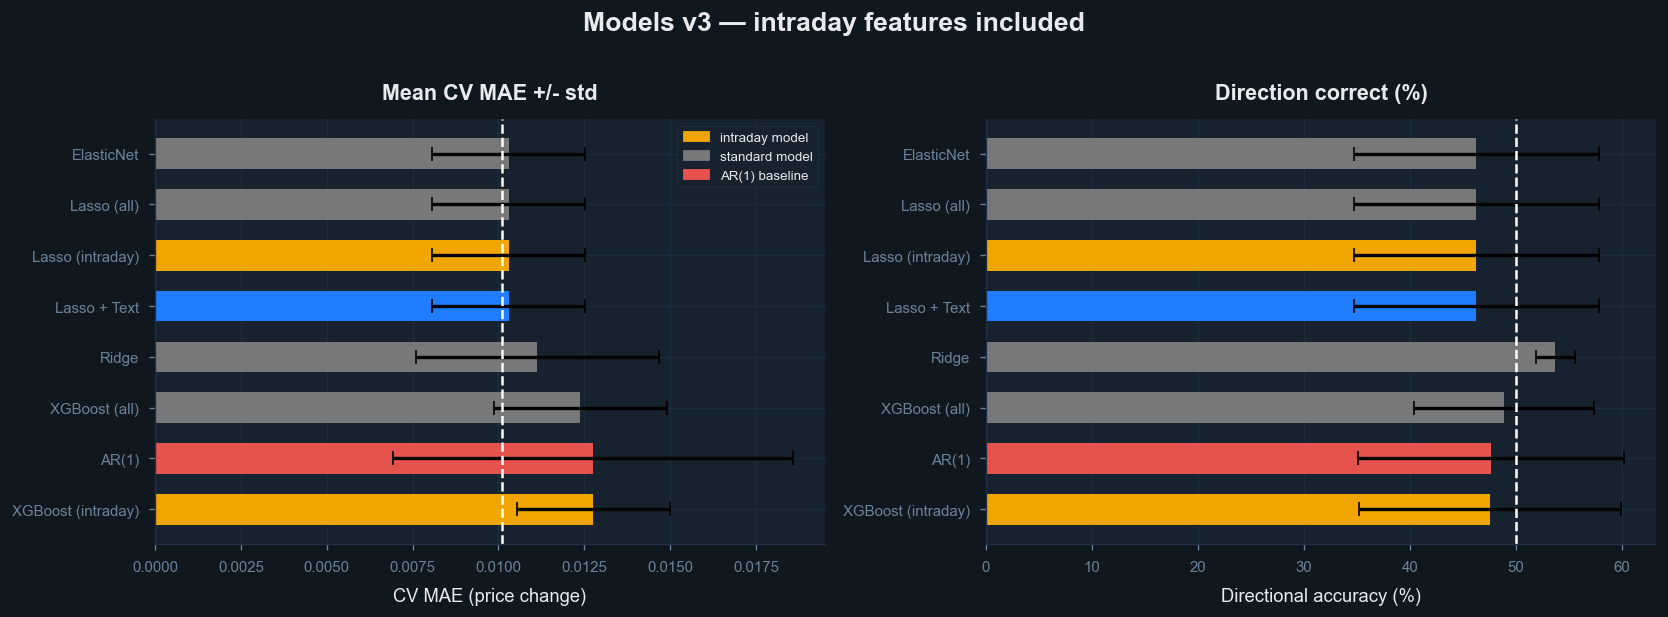

In [9]:
models_ord = summary.index.tolist()
means = summary['MAE_mean'].values
stds  = summary['MAE_std'].values

def _color(m):
    if 'intraday' in m: return '#f0a500'
    if 'Text' in m:     return DEMOCRAT
    if 'AR' in m:       return REPUBLICAN
    return NEUTRAL

colors = [_color(m) for m in models_ord]

fig, axes = styled_fig(1, 2, figsize=(14, 5),
    title="Models v3 — intraday features included")
ax1, ax2 = axes

ax1.barh(models_ord[::-1], means[::-1], xerr=stds[::-1],
         color=colors[::-1], capsize=4, height=0.6)
ax1.axvline(naive_mae_cv, color='white', ls='--', lw=1.5, label='Naive (predict 0)')
style_ax(ax1, xlabel='CV MAE (price change)', title='Mean CV MAE +/- std', grid_axis='x')
ax1.legend(fontsize=8)
patches = [mpatches.Patch(color='#f0a500', label='intraday model'),
           mpatches.Patch(color=NEUTRAL,   label='standard model'),
           mpatches.Patch(color=REPUBLICAN, label='AR(1) baseline')]
ax1.legend(handles=patches, fontsize=8)

dir_m = summary['DirAcc_mean'].values
dir_s = summary['DirAcc_std'].values
ax2.barh(models_ord[::-1], dir_m[::-1]*100, xerr=dir_s[::-1]*100,
         color=colors[::-1], capsize=4, height=0.6)
ax2.axvline(50, color='white', ls='--', lw=1.5)
style_ax(ax2, xlabel='Directional accuracy (%)', title='Direction correct (%)', grid_axis='x')
plt.tight_layout()
plt.show()

## Feature importance — what intraday features matter?

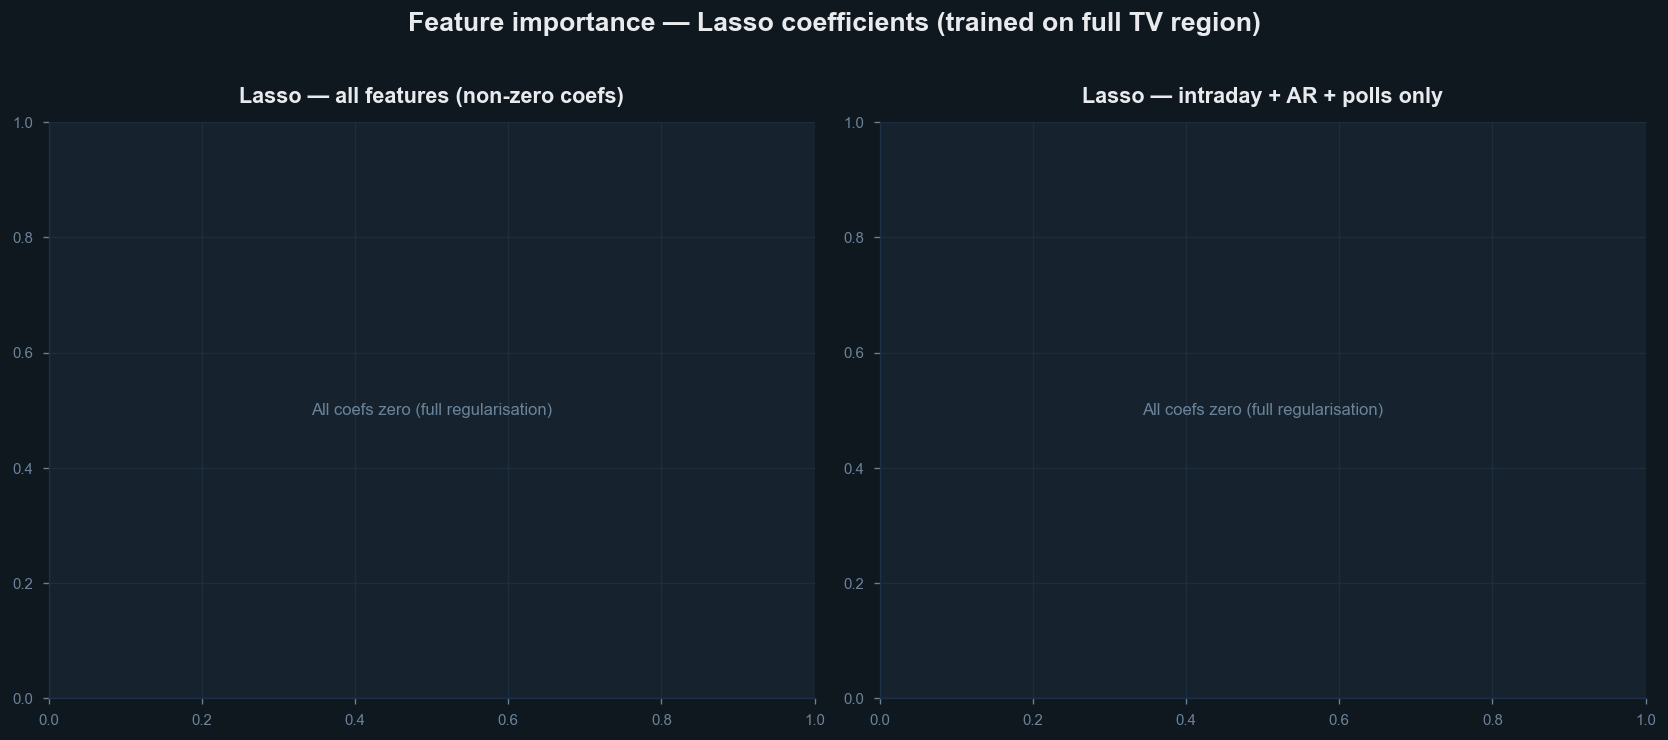

In [10]:
# Fit Lasso (all) and Lasso (intraday) on the full train+val region.
# Visualise which intraday features receive non-zero coefficients.

fig, axes = styled_fig(1, 2, figsize=(14, 6),
    title="Feature importance — Lasso coefficients (trained on full TV region)")
ax1, ax2 = axes

for ax, mname, title in [
    (ax1, 'Lasso (all)',      'Lasso — all features (non-zero coefs)'),
    (ax2, 'Lasso (intraday)', 'Lasso — intraday + AR + polls only'),
]:
    if mname not in TUNED_MODELS:
        ax.text(0.5, 0.5, 'Not available', ha='center', va='center',
                color=TEXT_MUTED, transform=ax.transAxes)
        continue
    p_m, f_m, _ = TUNED_MODELS[mname]
    p = clone(p_m)
    p.fit(df.iloc[tv_idx][f_m], df.iloc[tv_idx][TARGET])
    coefs = pd.Series(p['model'].coef_, index=f_m)
    coefs = coefs[coefs != 0].sort_values(key=abs, ascending=False).head(20)
    if len(coefs) == 0:
        ax.text(0.5, 0.5, 'All coefs zero (full regularisation)',
                ha='center', va='center', color=TEXT_MUTED, transform=ax.transAxes)
        style_ax(ax, title=title)
        continue
    # Highlight intraday features
    bar_colors = ['#f0a500' if '_lag1' in str(i) and any(
                      x in i for x in ['accel','burst','morning','evening'])
                  else REPUBLICAN if v > 0 else DEMOCRAT
                  for i, v in coefs.items()]
    ax.barh(range(len(coefs)), coefs.values[::-1], color=bar_colors[::-1])
    ax.set_yticks(range(len(coefs)))
    ax.set_yticklabels(coefs.index[::-1], fontsize=7, color=TEXT_PRIMARY)
    ax.axvline(0, color=TEXT_MUTED, lw=0.8)
    style_ax(ax, xlabel='Coefficient', title=title, grid_axis='x')
    patches = [mpatches.Patch(color='#f0a500', label='intraday feature'),
               mpatches.Patch(color=REPUBLICAN, label='+ve (bullish)'),
               mpatches.Patch(color=DEMOCRAT,   label='-ve (bearish)')]
    ax.legend(handles=patches, fontsize=7)

plt.tight_layout()
plt.show()

## Held-out test set evaluation

Final test set evaluation (14 held-out days — never touched during tuning):

Model                             MAE     RMSE       R2    DirAcc
--------------------------------------------------------------
AR(1)                          0.0161   0.0202    0.004    50.0%
Lasso (all)                    0.0162   0.0209   -0.067    50.0%
Lasso (intraday)               0.0162   0.0209   -0.067    50.0% <-- intraday
ElasticNet                     0.0162   0.0209   -0.067    50.0%
Ridge                          0.0156   0.0216   -0.142    50.0%
XGBoost (all)                  0.0176   0.0225   -0.243    57.1%


XGBoost (intraday)             0.0173   0.0243   -0.443    50.0% <-- intraday


Lasso + Text                   0.0162   0.0209   -0.067    50.0%


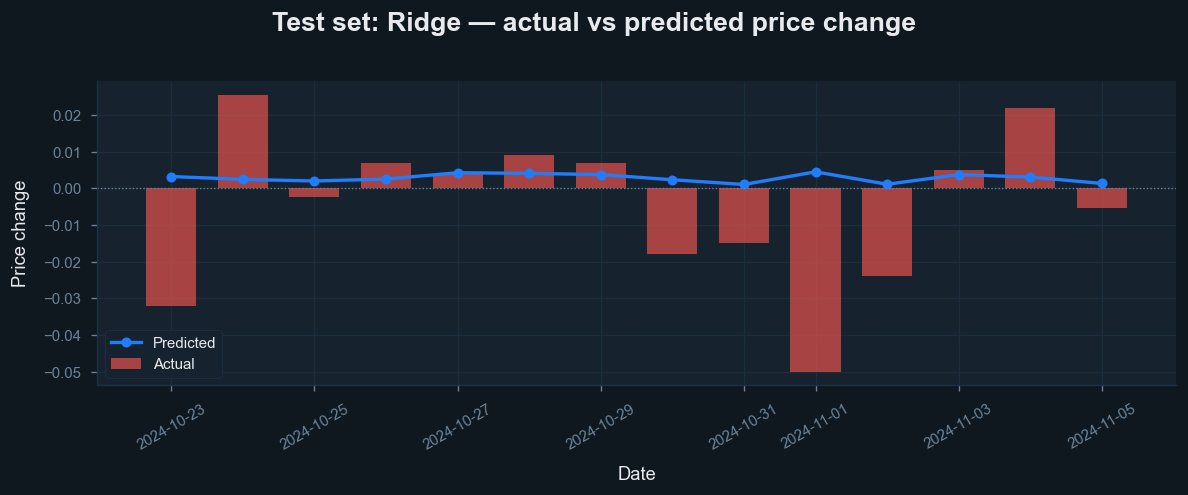


Best test model: Ridge  MAE=0.01562  DirAcc=50.0%


In [11]:
print("Final test set evaluation (14 held-out days — never touched during tuning):")
print()
print(f"{'Model':<28} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'DirAcc':>9}")
print("-" * 62)

test_results = []
for model_name, (pipeline, feat_cols, _ut) in TUNED_MODELS.items():
    p = clone(pipeline)
    p.fit(df.iloc[tv_idx][feat_cols], df.iloc[tv_idx][TARGET])
    y_pred = p.predict(df.iloc[test_idx][feat_cols])
    y_test = df.iloc[test_idx][TARGET].values
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    da   = directional_accuracy(y_test, y_pred)
    test_results.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'DirAcc': da})
    flag = ' <-- intraday' if 'intraday' in model_name else ''
    print(f"{model_name:<28} {mae:>8.4f} {rmse:>8.4f} {r2:>8.3f} {da:>8.1%}{flag}")

test_df_res = pd.DataFrame(test_results).sort_values('MAE').reset_index(drop=True)

# Plot test predictions for best model
best_name = test_df_res.iloc[0]['Model']
p2, f2, _ = TUNED_MODELS[best_name]
p2c = clone(p2)
p2c.fit(df.iloc[tv_idx][f2], df.iloc[tv_idx][TARGET])
y_tp = p2c.predict(df.iloc[test_idx][f2])
y_ta = df.iloc[test_idx][TARGET].values
test_dates = df.iloc[test_idx]['date']

fig, ax = styled_fig(1, 1, figsize=(10, 4),
    title=f"Test set: {best_name} — actual vs predicted price change")
ax.bar(test_dates, y_ta, color=REPUBLICAN, alpha=0.7, width=0.7, label='Actual')
ax.plot(test_dates, y_tp, color=DEMOCRAT, lw=2, marker='o', markersize=5, label='Predicted')
ax.axhline(0, color=TEXT_MUTED, lw=0.8, ls=':')
style_ax(ax, xlabel='Date', ylabel='Price change', grid_axis='y')
ax.legend()
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

print(f"\nBest test model: {best_name}  MAE={test_df_res.iloc[0]['MAE']:.5f}  "
      f"DirAcc={test_df_res.iloc[0]['DirAcc']:.1%}")